In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [2]:
df = pd.read_csv("../data/processed/combined_data.csv")

print(df.shape)
df.head()

(1965735, 2)


,text,target
0,Explanation Why the edits made under my userna...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,More I can't make any real suggestions on impr...,0
4,"You, sir, are my hero. Any chance you remember...",0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965735 entries, 0 to 1965734
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   text    object
 1   target  int64 
dtypes: int64(1), object(1)
memory usage: 30.0+ MB


text      1
target    0
dtype: int64

In [4]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)

target
0    0.908794
1    0.091206
Name: proportion, dtype: float64

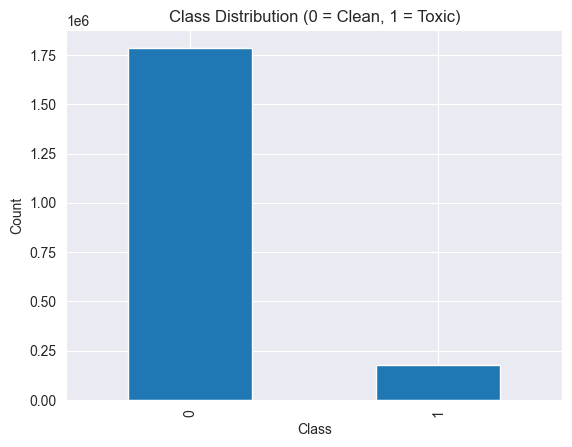

In [5]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Clean, 1 = Toxic)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [7]:
df['text_length'] = df['text'].str.len()

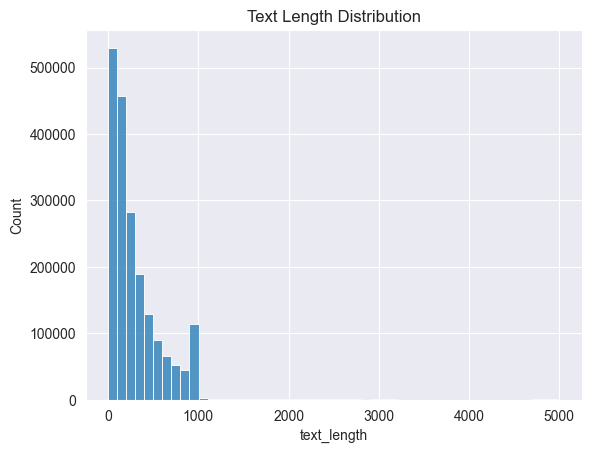

In [8]:
plt.figure()
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

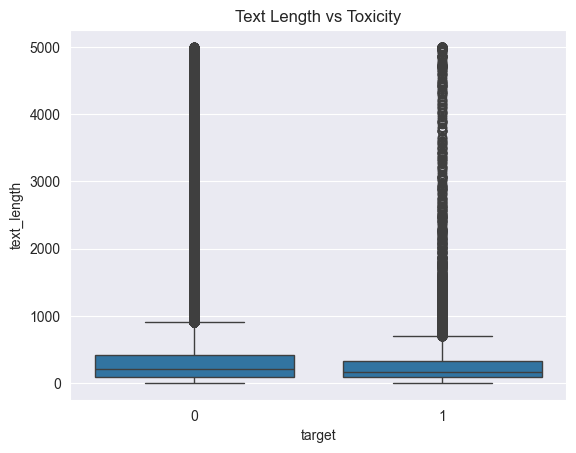

In [9]:
plt.figure()
sns.boxplot(x='target', y='text_length', data=df)
plt.title("Text Length vs Toxicity")
plt.show()

In [10]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

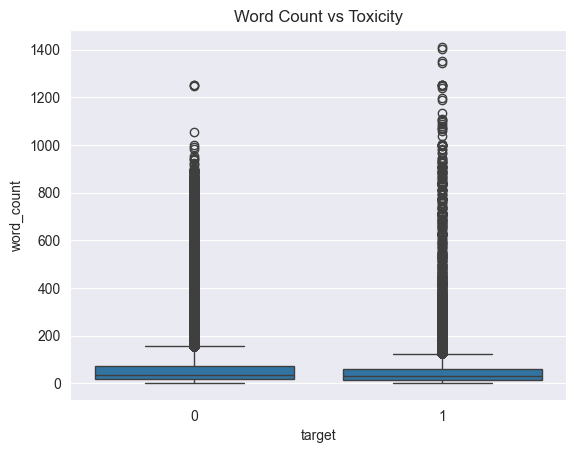

In [11]:
plt.figure()
sns.boxplot(x='target', y='word_count', data=df)
plt.title("Word Count vs Toxicity")
plt.show()

In [13]:
# Drop the NaNs from the 'text' column for target 0 before joining
clean_words = " ".join(df[df['target'] == 0]['text'].dropna()).split()

clean_common = Counter(clean_words).most_common(20)
clean_common

[('the', 4385940),
 ('to', 2691461),
 ('and', 2113592),
 ('of', 2079079),
 ('a', 1903274),
 ('is', 1485566),
 ('in', 1329800),
 ('that', 1211763),
 ('I', 970330),
 ('for', 934307),
 ('you', 796670),
 ('are', 708036),
 ('not', 651366),
 ('be', 650847),
 ('it', 644428),
 ('have', 620575),
 ('on', 614686),
 ('with', 565024),
 ('as', 501160),
 ('this', 451874)]

In [14]:
toxic_words = " ".join(df[df['target'] == 1]['text']).split()
toxic_common = Counter(toxic_words).most_common(20)

toxic_common

[('the', 309642),
 ('to', 202543),
 ('and', 183495),
 ('a', 179254),
 ('of', 154978),
 ('is', 130524),
 ('you', 97051),
 ('in', 92394),
 ('that', 90791),
 ('I', 80791),
 ('are', 70546),
 ('for', 70216),
 ('be', 48479),
 ('with', 47174),
 ('on', 47016),
 ('have', 46348),
 ('it', 45820),
 ('not', 45372),
 ('this', 40611),
 ('your', 39105)]

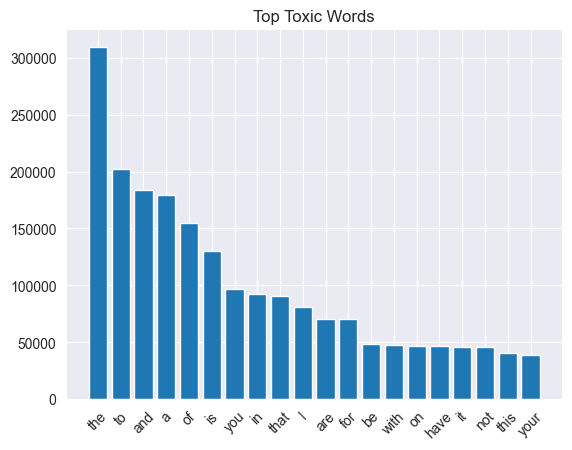

In [15]:
words, counts = zip(*toxic_common)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Toxic Words")
plt.show()

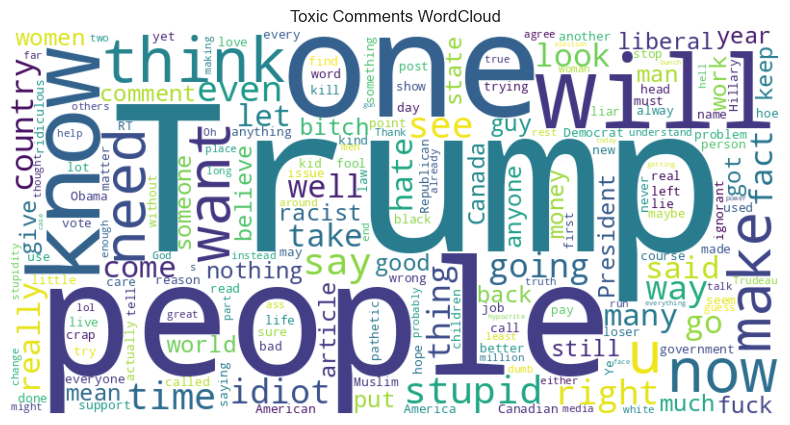

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Drop NaNs to avoid the 'expected str instance, float found' error
toxic_text = " ".join(df[df['target'] == 1]['text'].dropna())

# Generate and display
wc = WordCloud(width=800, height=400, background_color='white').generate(toxic_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Toxic Comments WordCloud")
plt.show()

In [20]:
import os

# Define the directory path
output_dir = "../outputs/eda/"

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# Now save your plot
plt.savefig(os.path.join(output_dir, "class_distribution.png"))

Created directory: ../outputs/eda/


<Figure size 640x480 with 0 Axes>

1. Dataset is highly imbalanced (~90% clean, ~10% toxic)

2. Toxic comments tend to:
   - Contain more aggressive language
   - Have specific repeated keywords

3. Clean comments are more diverse in vocabulary

4. Text length differences (mention what you observe)

5. Imbalance needs handling during model training